In [34]:
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from pyreadr import read_r
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
import json
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

BUNDLE_DIR = Path.cwd().resolve()
ROOT_DIR = BUNDLE_DIR.parents[0]
RESULTS_DIR = BUNDLE_DIR / "results"
DATA_DIR = ROOT_DIR / "data"
PROTEIN_DATA_DIR = DATA_DIR / "protein" / "aggregated_all"
EMBRYO_TRACKS_PATH = DATA_DIR / "c_briggsae" / "CD140715HLH1cbp1.csv"
EMBRYONIC_TERMINALS_PATH = DATA_DIR / "embryonic_terminals.txt"
# GENE_DATA_PATH = DATA_DIR / "gene_data.txt"
TISSUE_SPECIFIC_TF_PATH = PROTEIN_DATA_DIR / "tissue_specific_tf.tsv"
# AR_FEATURE_IMPORTANCE_PATH = RESULTS_DIR / "ar_feature_importance.tsv"
# AR_EMBEDDINGS_PATH = RESULTS_DIR / "ar_embeddings_32d.csv"
NN_EMBEDDINGS_PATH = RESULTS_DIR / "briggsae_embeddings_32d.csv"
# NN_SELECTED_PATH = RESULTS_DIR / "nn_selected_proteins_rev.tsv"
# S3_ZSCORE_PATH = PROTEIN_DATA_DIR / "s3_zscore.csv"
# LINEAGE_BINARY_EXPRESSION_PATH = PROTEIN_DATA_DIR / "lineage_binary_expression.csv"
# S3_PCA_10D_PATH = PROTEIN_DATA_DIR / "s3_pca_10d.csv"
# VISCELLO_EXPR_PATH = DATA_DIR / "viscello" / "lin_sc_expr_190602.rds"
CELL_TYPE_PATH = DATA_DIR / "2023-06-29_entropy_cell_key_V2.csv"
CELL_LINEAGE_PATH = DATA_DIR / "cell_lineage.json"

t_threshold = 180
ts_df = pd.read_csv(EMBRYO_TRACKS_PATH)
ts_df = ts_df.loc[ts_df["time"] <= t_threshold]
all_xyz_map = {}
cell_names = ts_df["cell"].unique()
valid_cell_names = []
for name in cell_names:
    time_points = ts_df.loc[ts_df['cell'] == name]["time"].values
    if len(time_points) == 1 and time_points[0] == t_threshold:
        continue
    all_xyz_map[name] = ts_df.loc[ts_df['cell'] == name].values[-1][8:11]
    valid_cell_names.append(name)

def map_names(did):
    if   did == "P4a": return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else: return did

embryonic_terminal_cells = pd.read_csv(EMBRYONIC_TERMINALS_PATH, sep='\t', header=None)[0].tolist()
tissue_specific_tfs = pd.read_csv(TISSUE_SPECIFIC_TF_PATH, sep='\t', header=None, index_col=0).index.tolist()
include_embryonic_terminals = False


In [35]:
alt_exp = pd.read_csv('../data/c_briggsae/science.adu8249/c_briggsae_tf_pca_20d.csv', index_col=0)
alt_exp

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
ABala,-457.073333,-253.215122,-526.671958,-452.062029,-711.852442,472.001375,-138.887646,76.345024,-512.835157,-114.792662,341.525136,1004.311922,166.796393,-177.227313,-283.782187,140.791444,254.252877,-29.639191,94.612169,337.153167
ABalaaa,-182.310011,-94.038321,-479.529759,-409.719278,-723.617230,553.682549,-252.150775,482.647412,-551.499296,-269.495454,208.688479,1204.793969,-130.579791,-175.648386,-243.826781,125.385896,652.625105,-129.106968,186.632935,426.249581
ABalaaaa,863.934235,1005.486881,-138.903186,-171.343216,-838.387382,237.506401,-871.653132,3251.840768,1908.681084,-1402.784157,-2622.117688,2024.467353,-3527.502255,-560.156390,-449.074667,603.367308,4275.254434,-1212.958966,583.622166,1881.017462
ABalaaaal,1692.180063,294.003340,-462.723866,-122.923753,-1002.582554,-266.794349,-540.445082,1716.830753,1573.770313,-591.247979,-1910.972805,896.258893,-2146.314075,-332.331187,-249.637368,160.674096,1891.999377,-519.620800,16.501173,1566.328309
ABalaaaala,-306.263849,3961.449587,1199.286213,-43.808185,-218.329158,-1968.237828,-2328.504798,8456.634277,4979.950245,-590.967911,-3747.890725,728.438398,-5127.140595,3.200604,-942.191587,-576.077633,900.152909,979.669472,747.399351,-481.925467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSppppp,-623.237680,-540.555097,-506.485027,-270.521066,-816.163267,-149.778350,-123.865602,-429.756419,30.959877,-115.858340,4.958757,-327.368917,11.170138,-155.555305,-457.140574,207.839656,-321.099941,-532.291316,564.845069,-544.983354
MSpppaap,-598.767534,-571.790534,-627.162783,-51.155162,-790.022417,-165.106731,-141.818971,-397.870304,1.574233,25.295575,-102.189074,-26.947936,-12.526326,-92.268043,-165.247033,-279.138216,-281.629886,-249.954941,221.840719,-262.638800
Z2,-617.244995,-552.564701,-623.618713,-343.455475,-1073.699337,-51.166972,-140.472702,-392.810538,-84.854368,124.384132,-349.598574,136.572175,138.612784,-87.904631,-200.733255,-224.309455,-160.628527,-80.514610,199.380211,-80.506895
Z3,-617.244995,-552.564701,-623.618713,-343.455475,-1073.699337,-51.166972,-140.472702,-392.810538,-84.854368,124.384132,-349.598574,136.572175,138.612784,-87.904631,-200.733255,-224.309455,-160.628527,-80.514610,199.380211,-80.506895


In [36]:
exp_embeddings = pd.read_csv(NN_EMBEDDINGS_PATH, index_col=0)
exp_embeddings

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_22,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31
cell_name,,,,,,,,,,,,,,,,,,,,,
ABala,0.504241,0.000000,0.000000,1.039623,0.000000,0.859177,0.804836,1.278898,0.000000,0.466449,...,0.000000,0.598631,1.200804,0.182451,2.518418,0.636645,0.408560,0.133255,0.000000,0.000000
ABalaaa,0.646688,0.000000,0.000000,1.587135,0.000000,0.319246,1.650548,0.000000,0.000000,0.000000,...,0.000000,0.776814,1.259259,0.000000,2.775265,2.605119,0.000000,0.000000,0.952274,0.000000
ABalaaaa,0.806608,0.000000,1.143725,1.682607,0.000000,0.000000,1.880291,0.000000,0.000000,0.000000,...,0.000000,0.765786,0.710793,0.000000,2.302206,3.697964,0.000000,0.000000,1.824302,0.000000
ABalaaaal,0.497171,0.000000,1.789366,1.495140,0.000000,0.000000,1.621418,0.000000,0.000000,0.000000,...,0.000000,0.277868,0.349896,0.000000,0.942217,2.909579,0.000000,0.000000,2.168927,0.000000
ABalaaaala,0.952289,2.174570,0.000000,1.193166,0.000000,0.535273,1.382022,0.581034,0.000000,1.129229,...,0.264864,0.000000,1.906119,0.634080,0.000000,2.028545,1.030158,0.000000,3.175463,0.056755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSppppp,0.000000,0.000000,0.000000,1.381902,1.457040,0.728214,1.670340,1.174833,1.455182,0.738302,...,0.856845,0.799759,0.816223,1.551906,0.000000,0.058467,1.287017,0.180822,0.000000,0.743721
MSpppaap,0.293245,2.515718,0.000000,0.472642,1.264631,0.115457,0.226189,2.346408,0.000000,1.190592,...,1.846016,0.000000,1.807427,0.000000,0.218827,0.028165,0.986861,0.000000,2.896325,2.281257
Z2,0.000000,2.066798,0.000000,0.926310,1.144384,0.644126,0.225715,1.014412,0.085625,0.663461,...,0.799828,0.134288,1.364734,1.807737,0.000000,0.000000,1.178564,0.000000,1.926315,0.730359


In [37]:
valid_cell_names = exp_embeddings.index.intersection(valid_cell_names).tolist()

In [38]:
len(valid_cell_names)

864

In [39]:
cell_type_df = pd.read_csv(CELL_TYPE_PATH)
lineage_type_dict = defaultdict(str)
for lineage in valid_cell_names:
    cur_cell_type_df = cell_type_df[cell_type_df['wormweb.lineage'] == lineage]
    if cur_cell_type_df.empty:
        continue
    cur_lineage_types = cur_cell_type_df["wormweb.type"]
    cur_lineage_types = cur_lineage_types[~cur_lineage_types.isna()].unique()
    if len(cur_lineage_types) == 0:
        continue
    lineage_type_dict[lineage] = cur_lineage_types[0]

In [40]:
with CELL_LINEAGE_PATH.open('r', encoding='utf-8') as f:
    lineage_data = json.load(f)

In [48]:
terminal_nodes = []
terminal_parents = []
terminal_parents_dict = defaultdict(list)
node_ancestry = defaultdict(list)
terminal_name_to_idx = {}
exp_valid_cell_names = exp_embeddings.index.tolist()

def dfs(node, parent, ancestors=[]):
    children = node.get("children", [])
    lookup_name = map_names(node["did"])
    node_ancestry[lookup_name] = ancestors
    if len(children) == 0 or (include_embryonic_terminals and lookup_name in embryonic_terminal_cells):
        p_lookup_name = map_names(parent['did'])
        if lookup_name in exp_valid_cell_names and p_lookup_name in exp_valid_cell_names:
            terminal_nodes.append(lookup_name)
            terminal_parents.append(p_lookup_name)
            terminal_parents_dict[p_lookup_name].append(lookup_name)
            terminal_name_to_idx[lookup_name] = len(terminal_nodes) - 1
    else:
        for child in children:
            dfs(child, node, ancestors + [lookup_name])

dfs(lineage_data, None)


In [49]:
def lineage_distance(cell1, cell2):
    ancestors1 = node_ancestry[cell1]
    ancestors2 = node_ancestry[cell2]
    common_ancestors = set(ancestors1).intersection(set(ancestors2))
    if not common_ancestors:
        return len(ancestors1) + len(ancestors2)
    last_common_ancestor = max(common_ancestors, key=lambda x: ancestors1.index(x))
    distance = (len(ancestors1) - ancestors1.index(last_common_ancestor) - 1) + (len(ancestors2) - ancestors2.index(last_common_ancestor) - 1)
    return distance

In [45]:
lineage_distances = []
exp_distances = []
for i in tqdm(range(len(exp_embeddings.index))):
    for j in range(i + 1, len(exp_embeddings.index)):
        cell1 = exp_embeddings.index[i]
        cell2 = exp_embeddings.index[j]
        dist = lineage_distance(cell1, cell2)
        exp_distance = np.linalg.norm(exp_embeddings.loc[cell1] - exp_embeddings.loc[cell2])
        exp_distances.append(exp_distance)
        lineage_distances.append(dist)
        # print(f"Lineage distance between {cell1} and {cell2}: {dist}")

100%|██████████| 1063/1063 [00:26<00:00, 40.54it/s] 


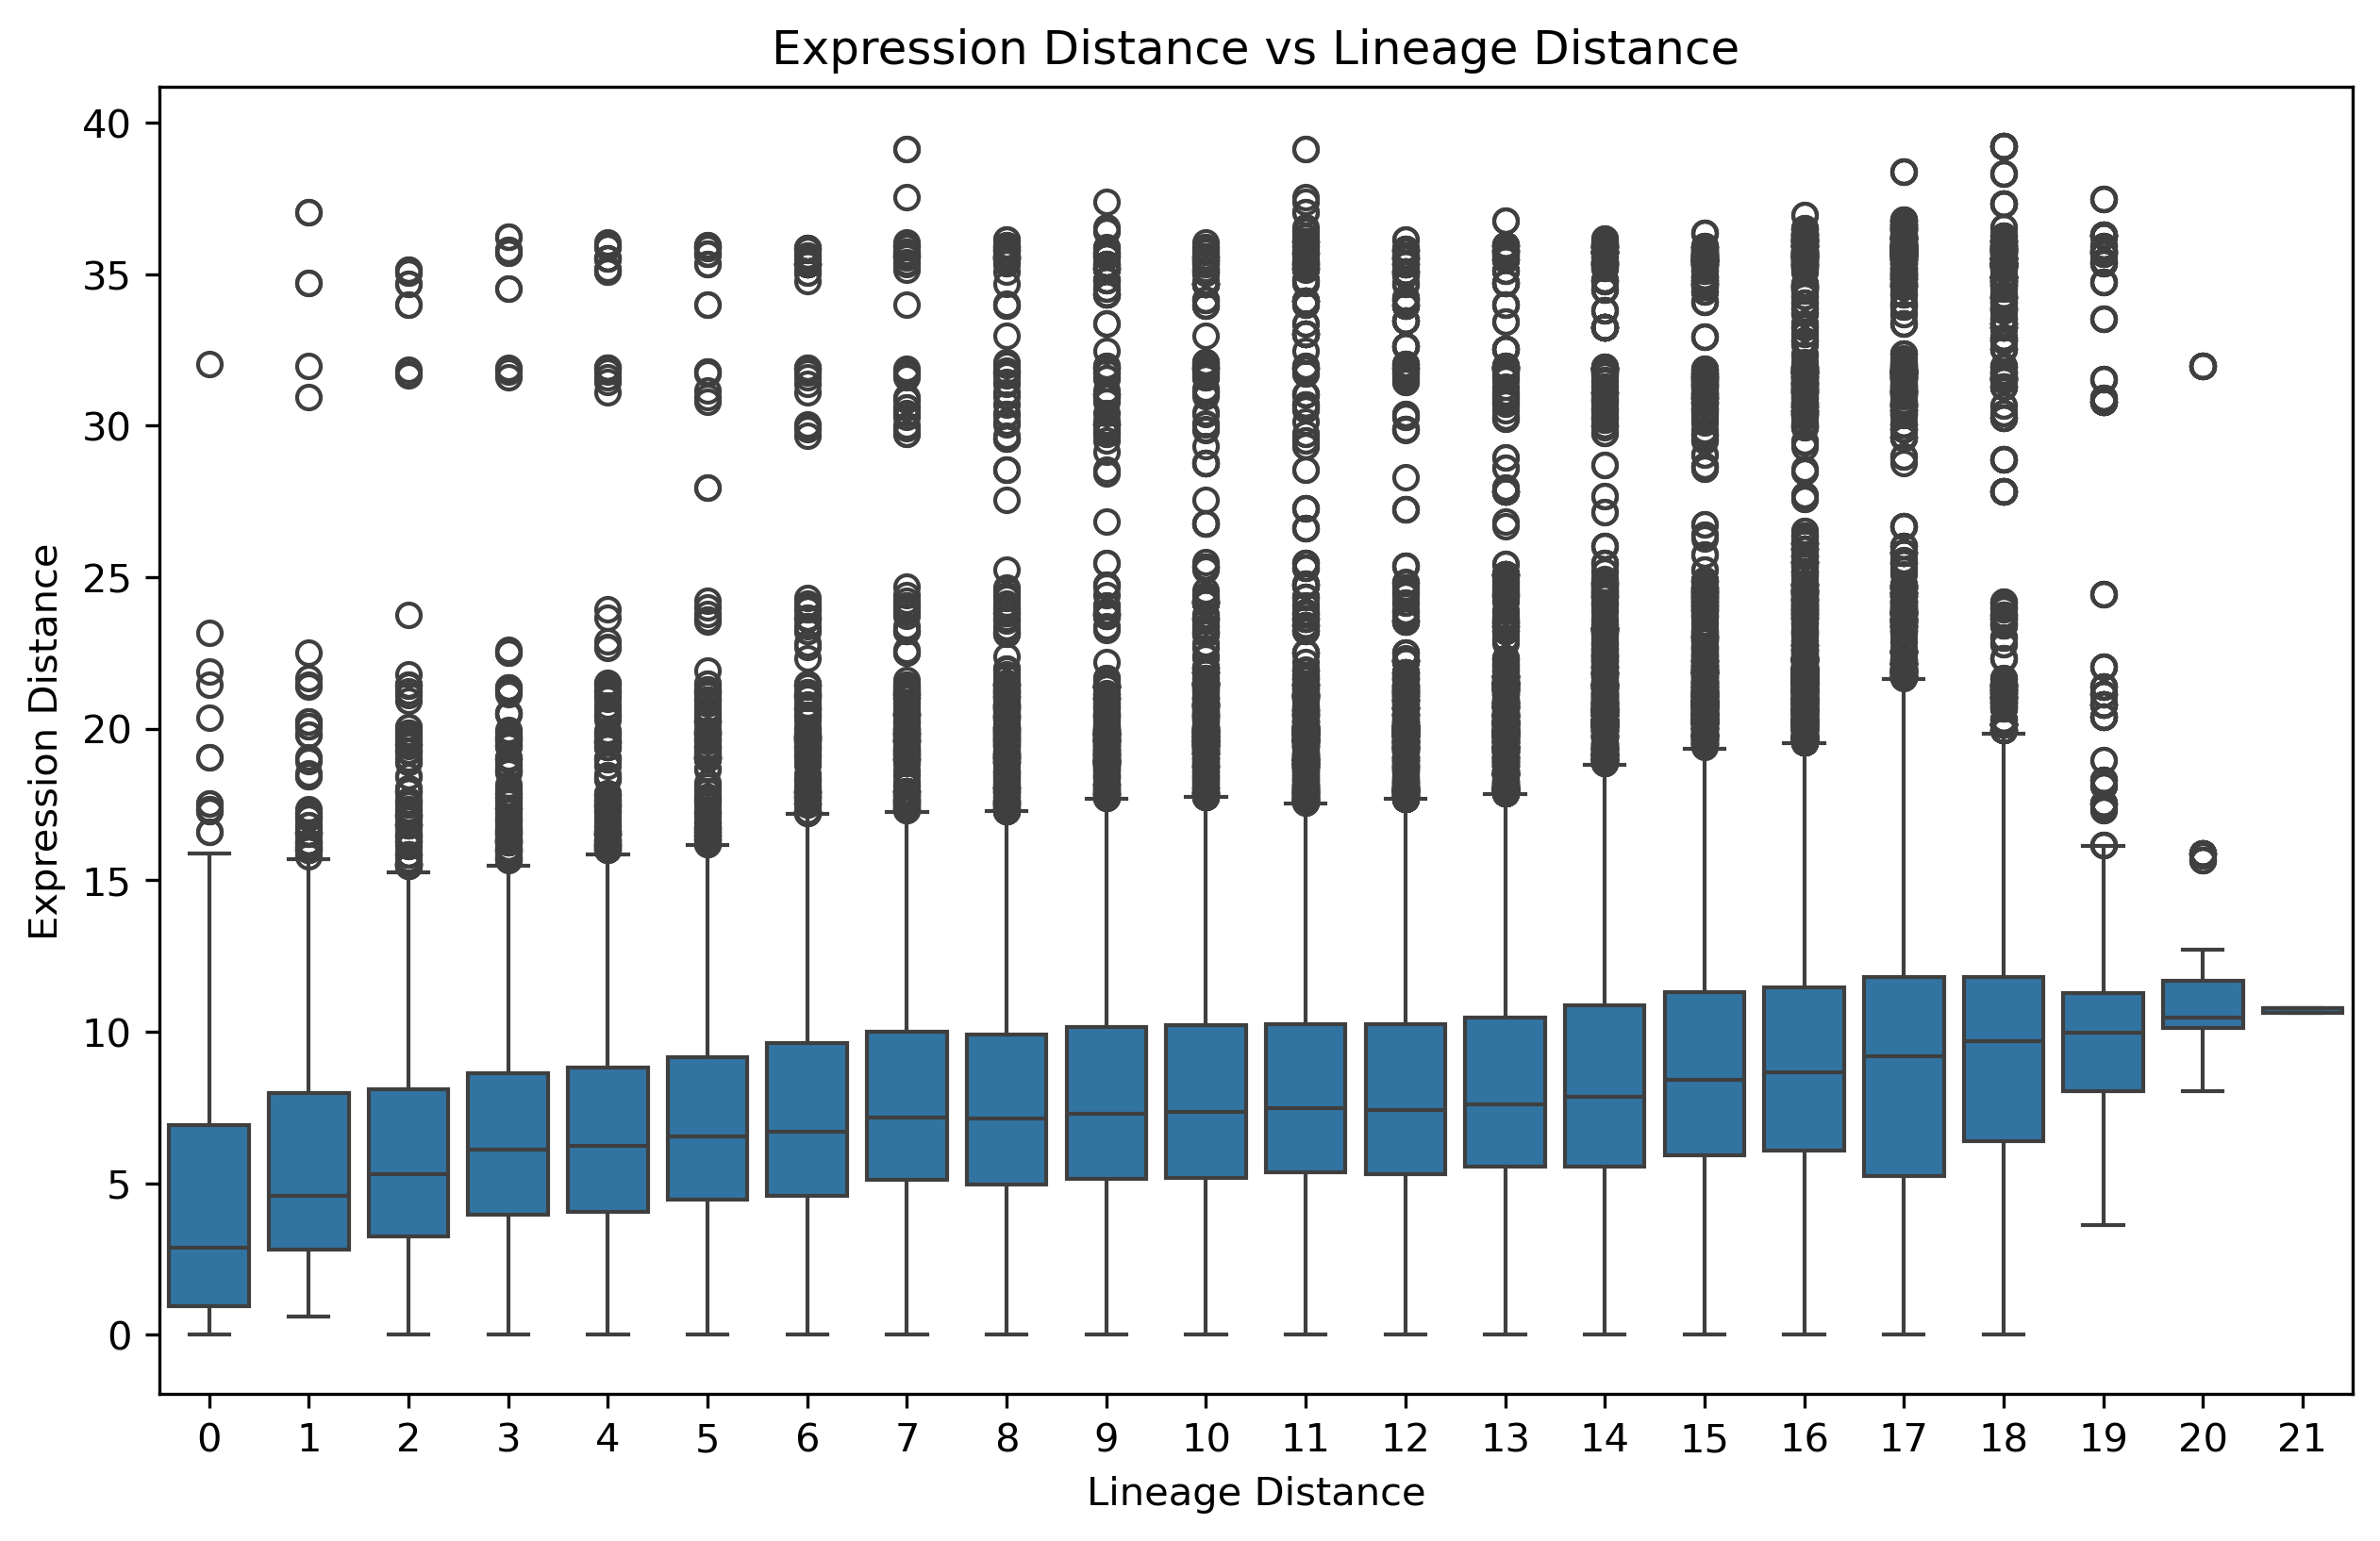

In [46]:
# plot lineage_distances againgst jsd_distances
# since lineage distance is discrete and jsd_distance is continuous we create a boxplot for each lineage distance
lineage_jsd_df = pd.DataFrame({'lineage_distance': lineage_distances, 'exp_distance': exp_distances})
plt.figure(figsize=(10, 6))
sns.boxplot(x='lineage_distance', y='exp_distance', data=lineage_jsd_df)
plt.title('Expression Distance vs Lineage Distance')
plt.xlabel('Lineage Distance')
plt.ylabel('Expression Distance')
plt.show()

In [50]:
same_type_siblings = []
diff_type_siblings = []
for parent, children in terminal_parents_dict.items():
    child_types = set()
    for child in children:
        child_type = lineage_type_dict.get(child, None)
        if child_type is not None:
            child_types.add(child_type)
    if len(child_types) == 1 and len(children) > 1:
        same_type_siblings.append(children)
    elif len(child_types) > 1:
        diff_type_siblings.append(children)


In [51]:
siblings_exp_distances_with_same_type = []
siblings_exp_distances_with_diff_type = []
sibling_parent_distances_with_same_type = []
sibling_parent_distances_with_diff_type = []

for parent, children in terminal_parents_dict.items():
    child_types = set()
    for child in children:
        child_type = lineage_type_dict.get(child, None)
        if child_type is not None:
            child_types.add(child_type)
    if len(child_types) == 1 and len(children) > 1:
        siblings_exp_distances_with_same_type.append(np.mean([np.linalg.norm(exp_embeddings.loc[child1] - exp_embeddings.loc[child2]) for i, child1 in enumerate(children) for j, child2 in enumerate(children) if i < j]))
        sibling_parent_distances_with_same_type.append(np.mean([np.linalg.norm(exp_embeddings.loc[child] - exp_embeddings.loc[parent]) for child in children]))
    elif len(child_types) > 1:
        siblings_exp_distances_with_diff_type.append(np.mean([np.linalg.norm(exp_embeddings.loc[child1] - exp_embeddings.loc[child2]) for i, child1 in enumerate(children) for j, child2 in enumerate(children) if i < j]))
        sibling_parent_distances_with_diff_type.append(np.mean([np.linalg.norm(exp_embeddings.loc[child] - exp_embeddings.loc[parent]) for child in children]))

    # if len(child_types) == 1 and len(children) > 1:
    #     siblings_exp_distances_with_same_type.append(
    #         np.mean([js_distance_matrix_df.loc[c1, c2]
    #                  for i, c1 in enumerate(children)
    #                  for j, c2 in enumerate(children) if i < j]))
    #     sibling_parent_distances_with_same_type.append(
    #         np.mean([js_distance_matrix_df.loc[c, parent] for c in children]))
    # elif len(child_types) > 1:
    #     siblings_exp_distances_with_diff_type.append(
    #         np.mean([js_distance_matrix_df.loc[c1, c2]
    #                  for i, c1 in enumerate(children)
    #                  for j, c2 in enumerate(children) if i < j]))
    #     sibling_parent_distances_with_diff_type.append(
    #         np.mean([js_distance_matrix_df.loc[c, parent] for c in children]))


In [52]:
print(f"Avg sibling expression distance with same type: {np.mean(siblings_exp_distances_with_same_type):.4f}")
print(f"Avg sibling expression distance with different type: {np.mean(siblings_exp_distances_with_diff_type):.4f}")
print(f"Avg sibling-parent expression distance with same type: {np.mean(sibling_parent_distances_with_same_type):.4f}")
print(f"Avg sibling-parent expression distance with different type: {np.mean(sibling_parent_distances_with_diff_type):.4f}")


Avg sibling expression distance with same type: 2.1651
Avg sibling expression distance with different type: 9.5957
Avg sibling-parent expression distance with same type: 5.6439
Avg sibling-parent expression distance with different type: 9.2814


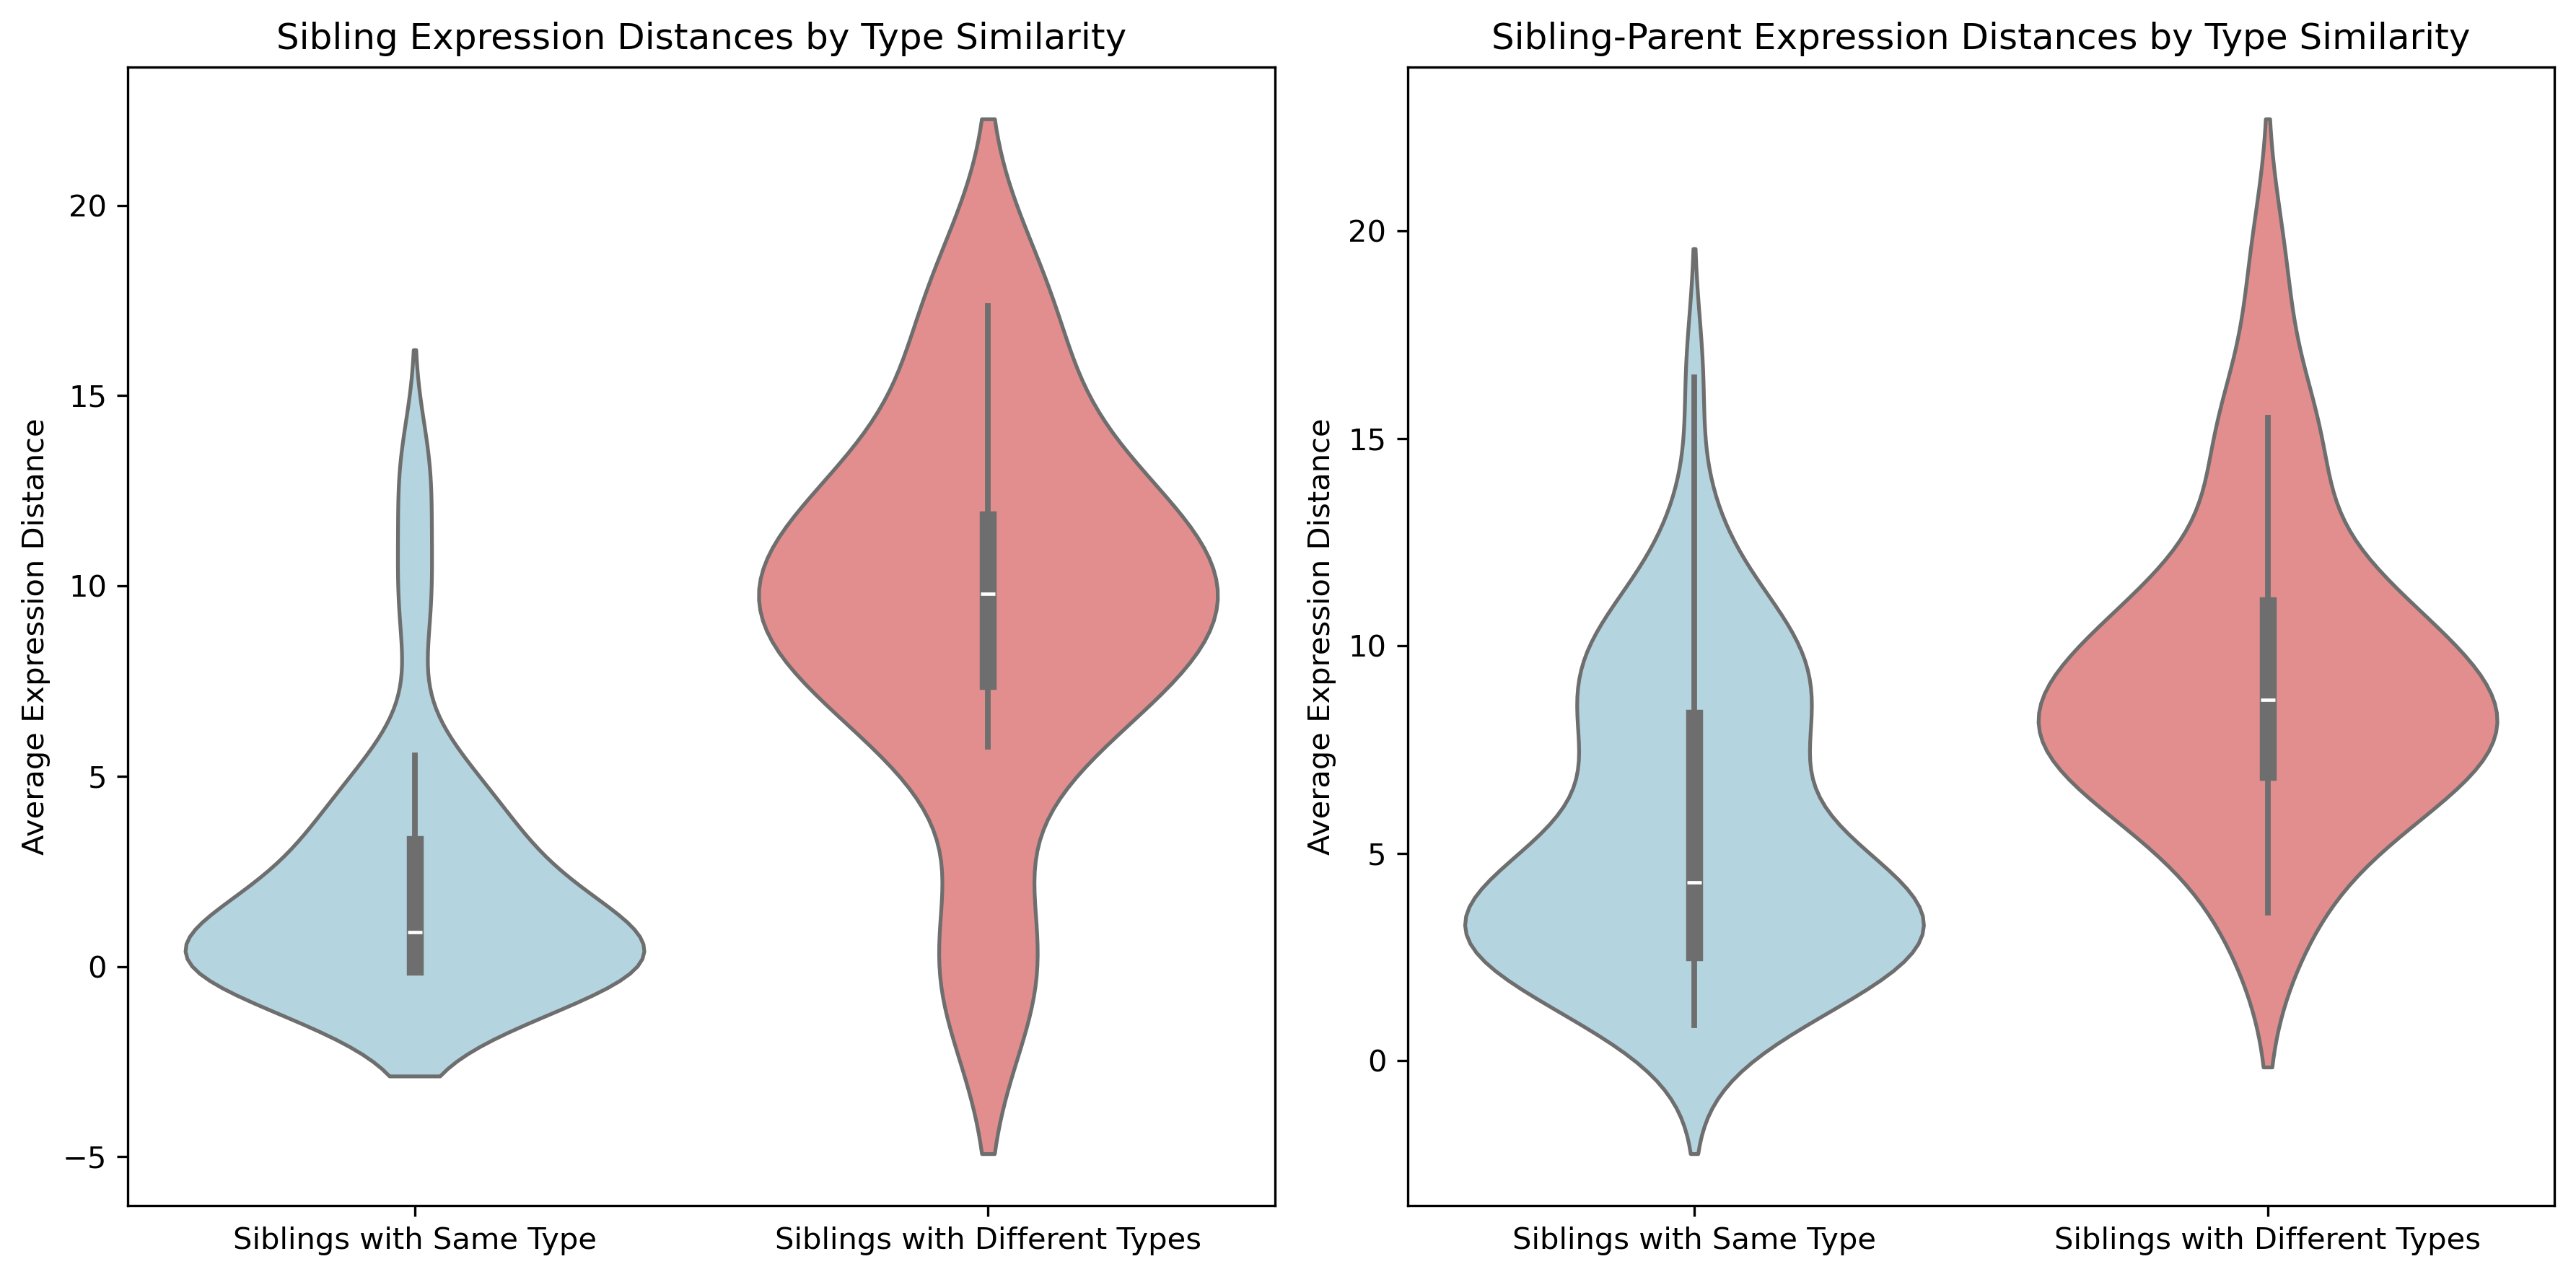

In [53]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.violinplot(data=[siblings_exp_distances_with_same_type, siblings_exp_distances_with_diff_type],
               palette=["lightblue", "lightcoral"])
plt.xticks([0, 1], ['Siblings with Same Type', 'Siblings with Different Types'])
plt.ylabel('Average Expression Distance')
plt.title('Sibling Expression Distances by Type Similarity')

plt.subplot(1, 2, 2)
sns.violinplot(data=[sibling_parent_distances_with_same_type, sibling_parent_distances_with_diff_type],
               palette=["lightblue", "lightcoral"])
plt.xticks([0, 1], ['Siblings with Same Type', 'Siblings with Different Types'])
plt.ylabel('Average Expression Distance')
plt.title('Sibling-Parent Expression Distances by Type Similarity')
plt.tight_layout()
plt.show()


In [54]:
terminal_nodes = []
terminal_parents = []
terminal_parents_dict = defaultdict(list)
node_ancestry = defaultdict(list)
terminal_name_to_idx = {}

def dfs(node, parent, ancestors=[]):
    children = node.get("children", [])
    lookup_name = map_names(node["did"])
    node_ancestry[lookup_name] = ancestors
    if len(children) == 0 or (include_embryonic_terminals and lookup_name in embryonic_terminal_cells):
        p_lookup_name = map_names(parent['did'])
        if lookup_name in valid_cell_names and p_lookup_name in valid_cell_names:
            terminal_nodes.append(lookup_name)
            terminal_parents.append(p_lookup_name)
            terminal_parents_dict[p_lookup_name].append(lookup_name)
            terminal_name_to_idx[lookup_name] = len(terminal_nodes) - 1
    else:
        for child in children:
            dfs(child, node, ancestors + [lookup_name])

dfs(lineage_data, None)


In [59]:
xyz_cost_mat = np.zeros((len(terminal_parents), len(terminal_nodes)))
alt_exp_cost_mat = np.zeros((len(terminal_parents), len(terminal_nodes)))
embedded_exp_cost_mat = np.zeros((len(terminal_parents), len(terminal_nodes)))

for i, parent in enumerate(terminal_parents):
    for j, node in enumerate(terminal_nodes):
        xyz_cost_mat[i, j] = np.linalg.norm(all_xyz_map[parent] - all_xyz_map[node])
        alt_exp_cost_mat[i, j] = np.linalg.norm(alt_exp.loc[parent] - alt_exp.loc[node])
        embedded_exp_cost_mat[i, j] = np.linalg.norm(exp_embeddings.loc[parent] - exp_embeddings.loc[node])

lineage_xyz_cost = xyz_cost_mat.diagonal().sum()
lineage_alt_exp_cost = alt_exp_cost_mat.diagonal().sum()
lineage_embedded_exp_cost = embedded_exp_cost_mat.diagonal().sum()


In [67]:
def pareto_exp_comp(chosen_exp_cost, title):
    pareto_xyz_costs = []
    pareto_alt_exp_costs = []
    pareto_house_keeping_exp_costs = []
    for i in tqdm(range(1001)):
        alpha = i / 1000.0
        combined_cost_mat = alpha * chosen_exp_cost + (1 - alpha) * xyz_cost_mat
        row_ind, col_ind = linear_sum_assignment(combined_cost_mat)
        pareto_xyz_costs.append(xyz_cost_mat[row_ind, col_ind].sum())
        pareto_alt_exp_costs.append(alt_exp_cost_mat[row_ind, col_ind].sum())
        pareto_house_keeping_exp_costs.append(embedded_exp_cost_mat[row_ind, col_ind].sum())
    
    def lineage_kept_ratio(cost_mat):
        row_ind, col_ind = linear_sum_assignment(cost_mat)
        print(np.argsort(row_ind == col_ind))
        print(len(row_ind))
        return np.sum(row_ind == col_ind) / len(row_ind)
    
    print(f"Lineage kept ratio for real lineage when optimizing for xyz: {lineage_kept_ratio(xyz_cost_mat):.4f}")
    print(f"Lineage kept ratio for real lineage when optimizing for alt_exp: {lineage_kept_ratio(alt_exp_cost_mat):.4f}")
    print(f"Lineage kept ratio for real lineage when optimizing for embedded_exp: {lineage_kept_ratio(embedded_exp_cost_mat):.4f}")

    fig, (ax2, ax3) = plt.subplots(2, 1, figsize=(6, 10), sharex=True)
    fig.suptitle(title)
    ax2.plot(pareto_xyz_costs, pareto_alt_exp_costs, marker='o', linestyle='-', color='black', markersize=3)
    ax2.scatter(lineage_xyz_cost, lineage_alt_exp_cost, marker='*', color='#FF0000', label='Real Lineage Cost')
    ax2.set_ylabel('ScRNA Cost')
    ax2.set_xlabel('Motility Cost')
    ax3.plot(pareto_xyz_costs, pareto_house_keeping_exp_costs, marker='o', linestyle='-', color='black', markersize=3)
    ax3.scatter(lineage_xyz_cost, lineage_embedded_exp_cost, marker='*', color='#FF0000', label='Real Lineage Cost')
    ax3.set_ylabel('Protein-Embedding Cost')
    ax3.set_xlabel('Motility Cost')
    plt.tight_layout()
    plt.show()


100%|██████████| 1001/1001 [00:01<00:00, 717.37it/s]


[  0 143 144 145 146 148 149 150 152 153 154 137 155 157 158 159 160 161
 162 165 167 168 169 156 170 136 134 106 107 108 109 110 111 113 116 117
 119 135 120 122 123 124 126 127 128 129 130 131 132 121 171 172 174 208
 210 211 212 213 214 215 217 218 219 206 220 222 224 225 226 227 228 229
 231 232 233 221 204 202 201 176 177 178 179 181 182 183 184 185 186 187
 188 189 190 191 193 194 195 196 197 198 199 200 105 104 118 102  36  37
  38  39  40  41  42  43  44  45  46  47  48  50  51  52 103  54  55  56
  57  58  59  35  61  34  32   2   3   4   6   7   8   9  10  13  14  15
  16  17  18  20  21  22  23  24  25  26  27  31  33  62  53  64  88  76
  78  79  80  93  82  83  84  63  92  85  86  90  87  95  74  89  97  65
  66 101  67 100  68  70  71  99  69  72   5 209 234 112  91 223   1  19
  98  11 114 230 235  96 115 216  94  12  30 205  60 163 164 166 151 147
 173 175  49  73  75 180 142 141 140 139 138  77 133 192  81  29  28 125
 203 207 236]
237
Lineage kept ratio for real linea

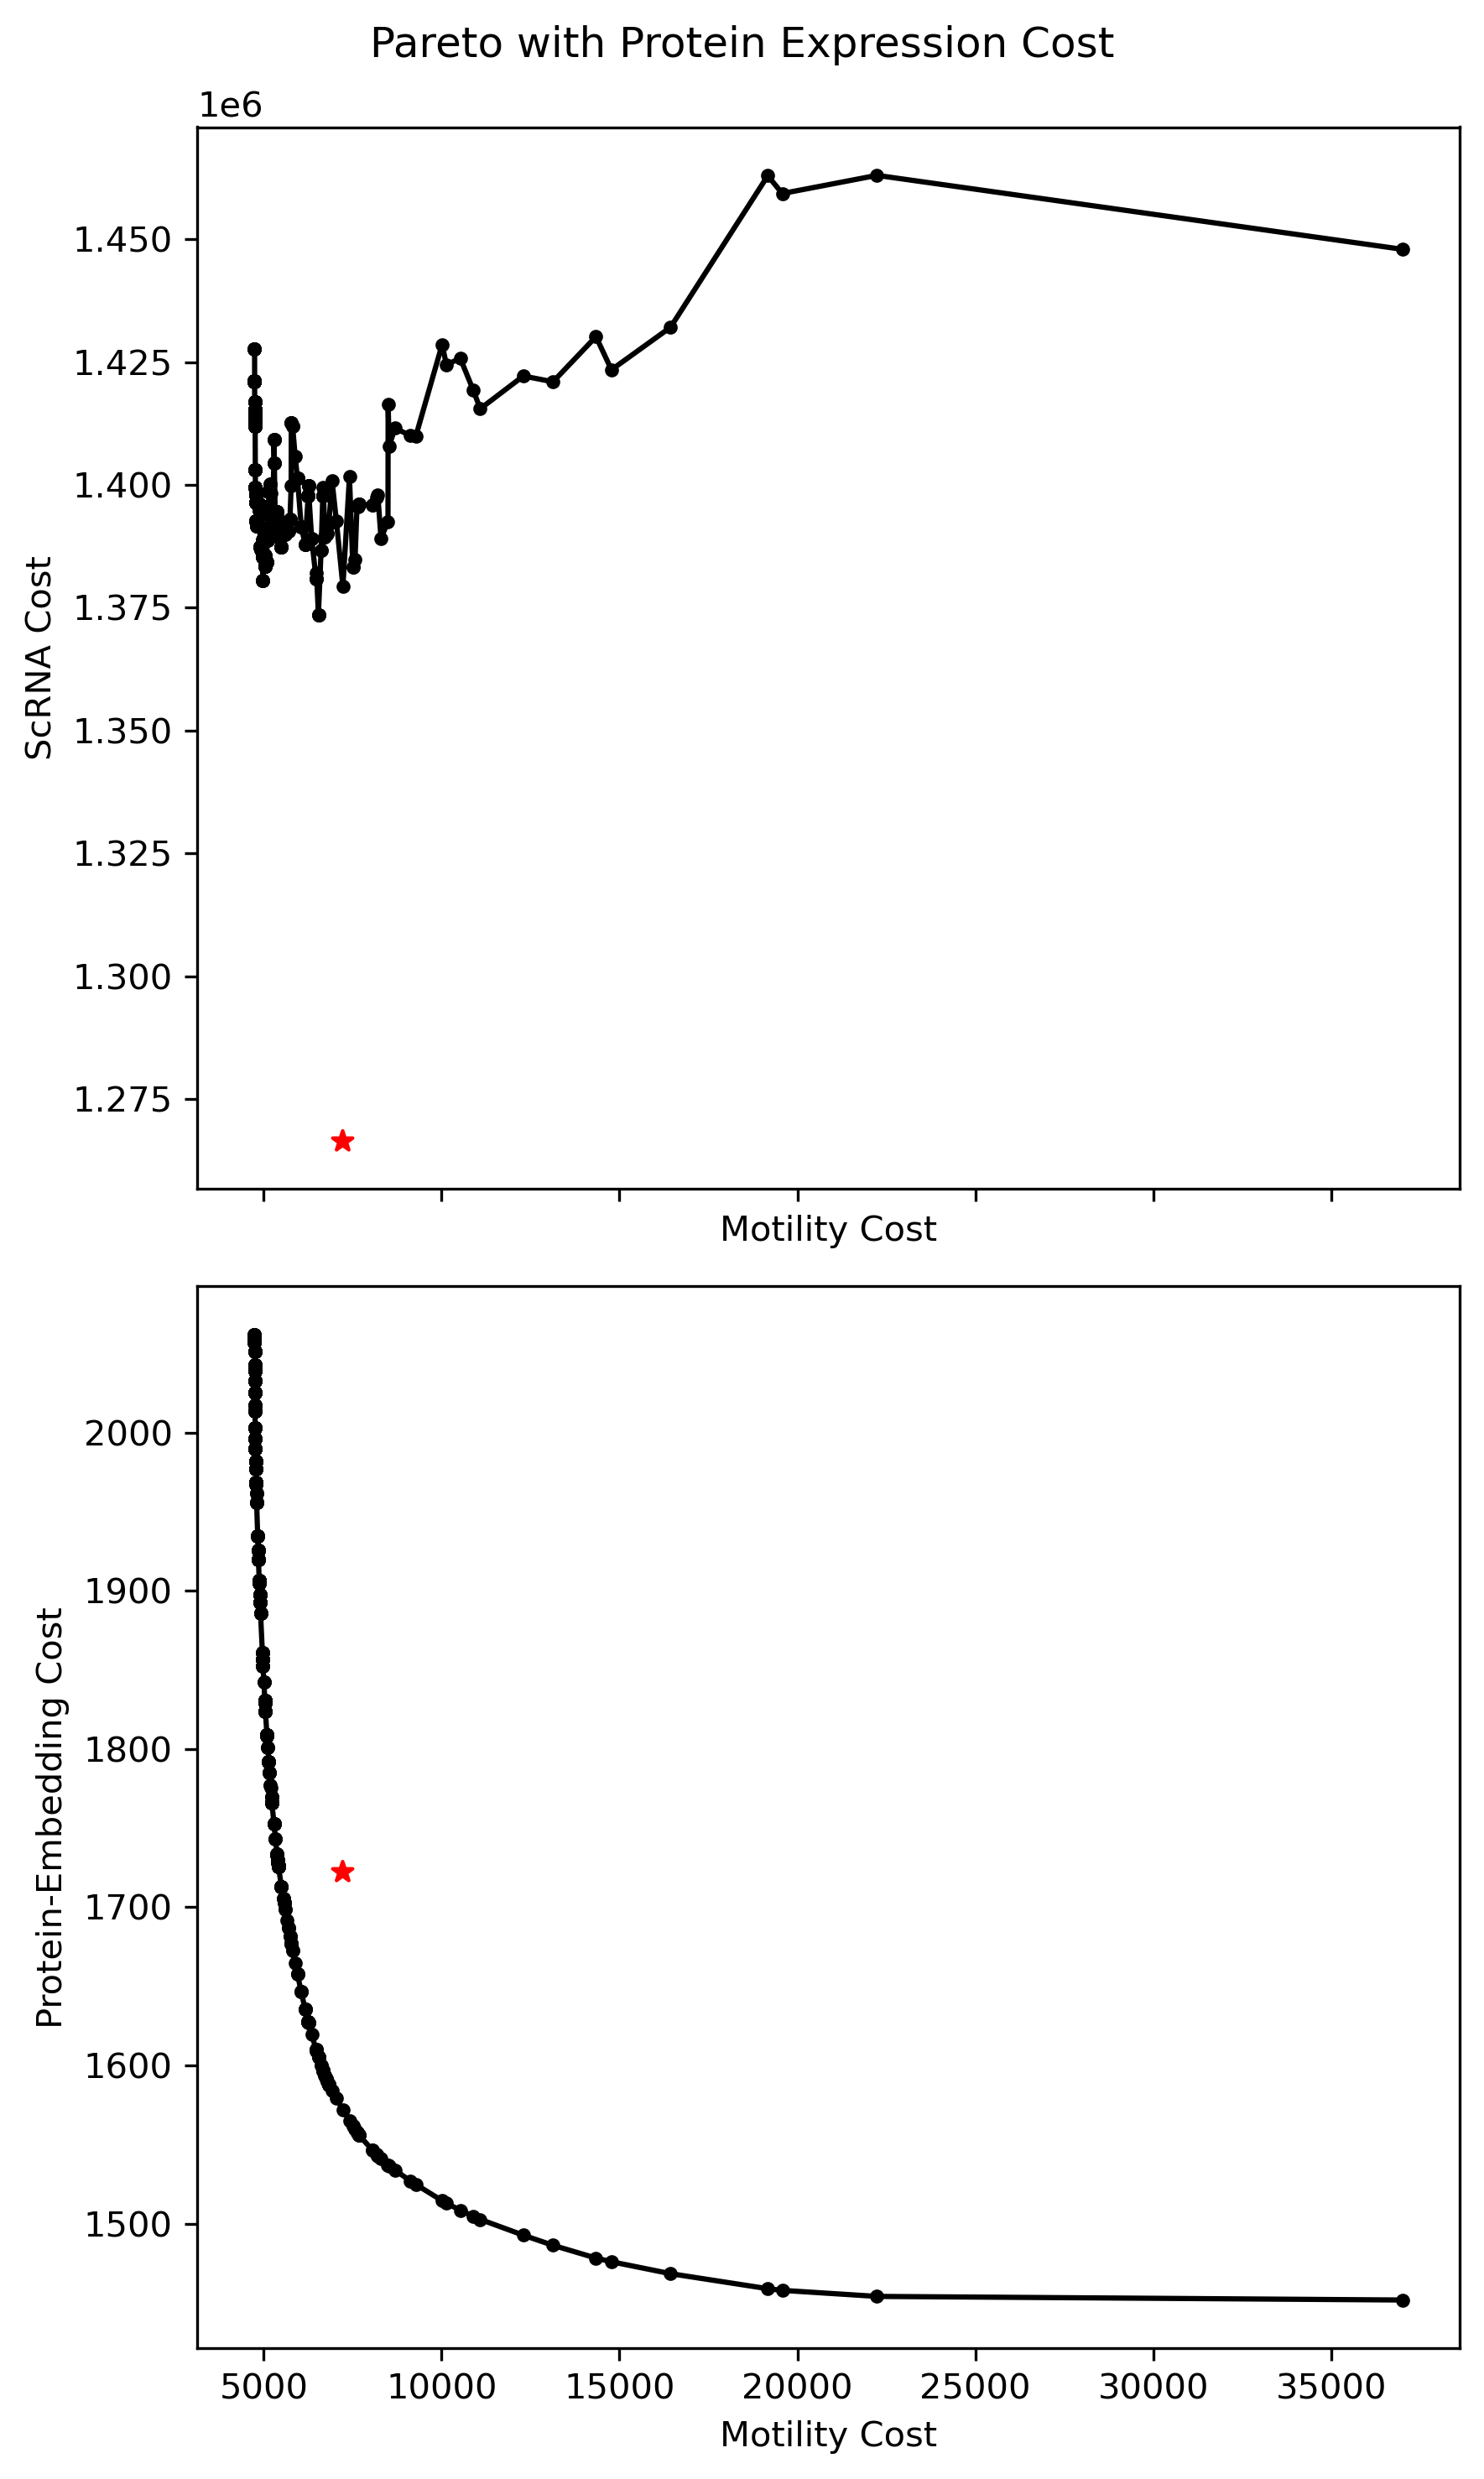

In [68]:
pareto_exp_comp(embedded_exp_cost_mat, "Pareto with Protein Expression Cost")


In [50]:
random_alt_exp_costs = []
for _ in tqdm(range(1000000)):
    col_ind = np.random.permutation(alt_exp_cost_mat.shape[0])
    row_ind = np.arange(alt_exp_cost_mat.shape[0])
    random_alt_exp_costs.append(alt_exp_cost_mat[row_ind, col_ind].sum())

100%|██████████| 1000000/1000000 [00:09<00:00, 108801.10it/s]


In [51]:
np.mean(random_alt_exp_costs), np.std(random_alt_exp_costs)

(np.float64(674.7331677597017), np.float64(8.590354441939507))

In [58]:
# get gene_data_df for candidate_tfs
candidate_tf_data_df = gene_data_df.loc[gene_data_df.index.isin(candidate_tfs)]

In [62]:
all_tf_data_df = gene_data_df.loc[gene_data_df.index.isin(name.upper() for name in tf_names)]

In [64]:
candidate_tf_data_df["cel_tau_median_joint"].mean()

np.float64(0.5220147063394972)

In [65]:
all_tf_data_df["cel_tau_median_joint"].mean()

np.float64(0.653863455282491)